To analyze coffee shop transaction data to:

Understand sales patterns

Compare payment methods (cash vs card)

Identify top-selling beverages

Analyze revenue trends over time

Generate actionable business insights

In [1]:
#imports
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns',None)
sns.set_style('whitegrid')


In [2]:
df1= pd.read_csv('../Data/index_1.csv')
df2= pd.read_csv('../Data/index_2.csv')

In [3]:
#inspet data drames
df1.head()


,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte


In [4]:
df2.head(10)

,date,datetime,cash_type,money,coffee_name
0,2025-02-08,2025-02-08 14:26:04,cash,15.0,Tea
1,2025-02-08,2025-02-08 14:28:26,cash,15.0,Tea
2,2025-02-08,2025-02-08 14:33:04,card,20.0,Espresso
3,2025-02-08,2025-02-08 15:51:04,card,30.0,Chocolate with coffee
4,2025-02-08,2025-02-08 16:35:01,cash,27.0,Chocolate with milk
5,2025-02-08,2025-02-08 18:55:30,card,33.0,Espresso
6,2025-02-08,2025-02-08 18:59:03,cash,29.0,Coffee with Irish whiskey
7,2025-02-08,2025-02-08 19:00:28,cash,27.0,Irish whiskey with milk
8,2025-02-09,2025-02-09 08:45:45,card,28.0,Double Irish whiskey
9,2025-02-09,2025-02-09 10:41:36,cash,30.0,Chocolate with coffee


In [5]:
df1.tail()





,date,datetime,cash_type,card,money,coffee_name
3631,2025-03-23,2025-03-23 10:34:54.894,card,ANON-0000-0000-1158,35.76,Cappuccino
3632,2025-03-23,2025-03-23 14:43:37.362,card,ANON-0000-0000-1315,35.76,Cocoa
3633,2025-03-23,2025-03-23 14:44:16.864,card,ANON-0000-0000-1315,35.76,Cocoa
3634,2025-03-23,2025-03-23 15:47:28.723,card,ANON-0000-0000-1316,25.96,Americano
3635,2025-03-23,2025-03-23 18:11:38.635,card,ANON-0000-0000-1275,35.76,Latte


In [6]:
df2.tail()

,date,datetime,cash_type,money,coffee_name
257,2025-03-23,2025-03-23 14:55:46,cash,30.0,Cappuccino
258,2025-03-23,2025-03-23 15:15:36,card,25.0,Irish whiskey
259,2025-03-23,2025-03-23 17:59:25,card,28.0,Super chocolate
260,2025-03-23,2025-03-23 18:01:33,card,28.0,Vanilla with Irish whiskey
261,2025-03-23,2025-03-23 21:23:11,card,29.0,Coffee with Irish whiskey


In [7]:
df1.shape




(3636, 6)

In [8]:
df2.shape

(262, 5)

In [9]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3636 entries, 0 to 3635
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         3636 non-null   object 
 1   datetime     3636 non-null   object 
 2   cash_type    3636 non-null   object 
 3   card         3547 non-null   object 
 4   money        3636 non-null   float64
 5   coffee_name  3636 non-null   object 
dtypes: float64(1), object(5)
memory usage: 170.6+ KB


In [10]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 262 entries, 0 to 261
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         262 non-null    object 
 1   datetime     262 non-null    object 
 2   cash_type    262 non-null    object 
 3   money        262 non-null    float64
 4   coffee_name  262 non-null    object 
dtypes: float64(1), object(4)
memory usage: 10.4+ KB


In [11]:
df1.describe()

,money
count,3636.000000
mean,31.746859
std,4.919926
min,18.120000
25%,27.920000
50%,32.820000
75%,35.760000
max,40.000000


In [12]:
df1.isnull().mean()*100

date           0.000000
datetime       0.000000
cash_type      0.000000
card           2.447745
money          0.000000
coffee_name    0.000000
dtype: float64

In [13]:
df2.isnull().mean()*100

date           0.0
datetime       0.0
cash_type      0.0
money          0.0
coffee_name    0.0
dtype: float64

In [14]:
df1['date']=pd.to_datetime(df1['date'])
df1['datetime']=pd.to_datetime(df1['datetime'])

df2['date']=pd.to_datetime(df2['date'])
df2['datetime']=pd.to_datetime(df2['datetime'])

In [15]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3636 entries, 0 to 3635
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         3636 non-null   datetime64[ns]
 1   datetime     3636 non-null   datetime64[ns]
 2   cash_type    3636 non-null   object        
 3   card         3547 non-null   object        
 4   money        3636 non-null   float64       
 5   coffee_name  3636 non-null   object        
dtypes: datetime64[ns](2), float64(1), object(3)
memory usage: 170.6+ KB


In [16]:
df1.head()

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte


In [17]:
df1.drop_duplicates(inplace=True)
df2.drop_duplicates(inplace=True)

In [18]:
df=pd.concat([df1,df2],ignore_index=True)

In [19]:
df.head()

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte


In [20]:
df.shape

(3896, 6)

In [21]:
#convert money column into numpy array
money_array=np.array(df['money'])
money_array[2:10]

array([38.7, 28.9, 38.7, 33.8, 38.7, 33.8, 38.7, 33.8])

In [22]:
np.mean(money_array)
np.median(money_array)
np.std(money_array)

5.063195323909365

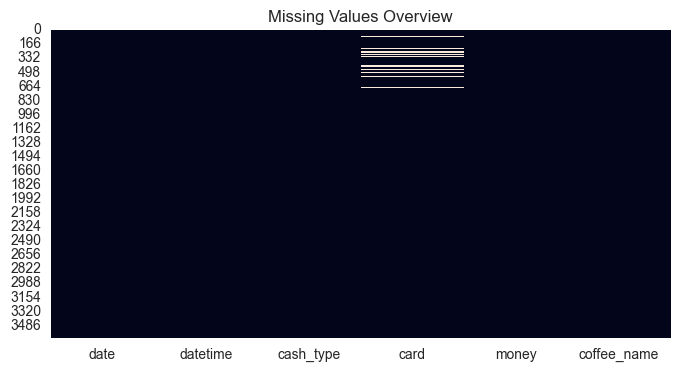

In [23]:

plt.figure(figsize=(8,4))
sns.heatmap(df1.isnull(), 
            cbar=False, 
            )
plt.title("Missing Values Overview")
plt.show()

In [24]:
total_revenue=df['money'].sum()
total_revenue

122271.57999999999

In [25]:
df.groupby('cash_type')['money'].sum()

cash_type
card    117114.58
cash      5157.00
Name: money, dtype: float64

In [26]:
df['cash_type'].value_counts()

cash_type
card    3729
cash     167
Name: count, dtype: int64

In [27]:
df['coffee_name'].unique()


array(['Latte', 'Hot Chocolate', 'Americano', 'Americano with Milk',
       'Cocoa', 'Cortado', 'Espresso', 'Cappuccino', 'Tea',
       'Chocolate with coffee', 'Chocolate with milk',
       'Coffee with Irish whiskey', 'Irish whiskey with milk',
       'Double Irish whiskey', 'Double espresso', 'Americano with milk',
       'Double espresso with milk', 'Caramel with Irish whiskey',
       'Super chocolate', 'Double vanilla', 'Mochaccino',
       'Caramel with chocolate', 'Irish whiskey', 'Caramel coffee',
       'Vanilla with Irish whiskey', 'Chocolate', 'Caramel with milk',
       'Coffee with chocolate', 'Irish with chocolate', 'Vanilla coffee',
       'Double ristretto', 'Hot milkshake', 'Double chocolate', 'Caramel'],
      dtype=object)

In [28]:
df['coffee_name'].value_counts().head()


coffee_name
Americano with Milk    824
Latte                  806
Americano              593
Cappuccino             517
Cortado                292
Name: count, dtype: int64

In [29]:
vc= df['coffee_name'].value_counts()
top5=vc[vc >=vc.iloc[4]]
top5

coffee_name
Americano with Milk    824
Latte                  806
Americano              593
Cappuccino             517
Cortado                292
Name: count, dtype: int64

In [30]:
df.groupby('coffee_name')['money'].sum().sort_values(ascending=False)

coffee_name
Latte                         28658.30
Americano with Milk           25269.12
Cappuccino                    18514.14
Americano                     15437.26
Hot Chocolate                 10172.46
Cocoa                          8678.16
Cortado                        7534.86
Espresso                       3187.28
Americano with milk            1050.00
Irish whiskey                   525.00
Coffee with Irish whiskey       464.00
Irish whiskey with milk         405.00
Double Irish whiskey            336.00
Chocolate with milk             324.00
Tea                             240.00
Caramel with Irish whiskey      224.00
Super chocolate                 168.00
Mochaccino                      150.00
Chocolate with coffee           150.00
Irish with chocolate            135.00
Caramel with chocolate          112.00
Vanilla with Irish whiskey       84.00
Caramel with milk                75.00
Double espresso with milk        64.00
Caramel coffee                   56.00
Double vanill